In [1]:

import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial import cKDTree
import torch
import thomas_npe as T    
SEED = 42
RNG  = np.random.default_rng(SEED)
torch.manual_seed(SEED)

# Set matplotlib parameters for academic publication
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "text.usetex": True, # Requires LaTeX installation
})


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

---
## 1 · The Thomas Cluster Process

### 1.1 Generative model

The **Thomas (Neyman–Scott) process** \[Thomas 1949; Neyman & Scott 1958\]
is a hierarchical spatial point process defined by two steps:

1. Scatter $N_{\text{parent}} \sim \text{Poisson}(\lambda_p)$
   **cluster centres** uniformly in $[0,1]^2$.

2. Around each centre $\mathbf{c}_j$, generate
   $N_j \sim \text{Poisson}(\mu)$ **galaxies** at positions

$$
\mathbf{x}_{jk} = \mathbf{c}_j + \boldsymbol{\varepsilon}_{jk},
\qquad
\boldsymbol{\varepsilon}_{jk} \sim \mathcal{N}\!\left(\mathbf{0},\,\sigma^2 \mathbf{I}\right).
$$

We **fix** $\lambda_p = 20$ and **infer** $(\mu, \sigma)$ from the galaxy
positions.


### 1.2 Known power spectrum

The two-point power spectrum of the Thomas process is:

$$
P_{\text{Thomas}}(k) = \frac{1}{\lambda_p}
\!\left[1 + \lambda_p \mu^2 \exp\!\left(-k^2 \sigma^2\right)\right].
$$

This tells us:
- $\mu$ raises the **large-scale amplitude** (more galaxies per cluster).
- $\sigma$ sets the **roll-off scale** (wider clusters decay at lower $k$).

### 1.3 Physical analogy

| Thomas parameter | Physical analogue |
|-----------------|-------------------|
| $\lambda_p$ | Halo number density |
| $\mu$ | Mean halo occupation $\langle N \mid M \rangle$ (HOD) |
| $\sigma$ | Halo virial radius / concentration |

### 1.4 Prior

We place a uniform prior over the inference parameters:

$$
\mu \sim \mathcal{U}[3, 25], \qquad
\sigma \sim \mathcal{U}[0.02, 0.12].
$$

In [2]:
# ── Inspect the module constants ──────────────────────────────────────────────
print(f"Fixed parent count  λ_p = {T.LAMBDA_P}")
print(f"Prior on μ           : [{T.MU_LO},  {T.MU_HI}]")
print(f"Prior on σ           : [{T.SIG_LO}, {T.SIG_HI}]")

Fixed parent count  λ_p = 20
Prior on μ           : [3.0,  25.0]
Prior on σ           : [0.02, 0.12]


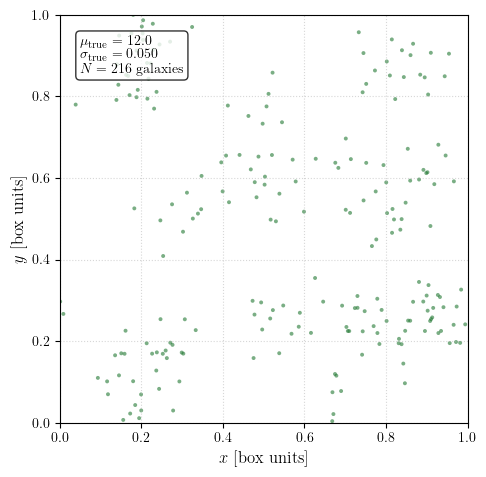

In [3]:
MU_TRUE    = 12.0
SIGMA_TRUE = 0.050

# Simulate the "observed" catalog
rng_obs = np.random.default_rng(123)          # held-out seed
x_obs   = T.simulate_thomas(MU_TRUE, SIGMA_TRUE, rng_obs)

fig, ax = plt.subplots(figsize=(5, 5))

# Use a professional color and finer point marker
ax.scatter(x_obs[:, 0], x_obs[:, 1], s=8, alpha=0.6, c="#227833", edgecolor='none')

# Configure axes for clarity
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$ [box units]")
ax.set_ylabel(r"$y$ [box units]")

# Add a subtle grid
ax.grid(True, linestyle=':', alpha=0.5)

# Add informative annotation inside the plot instead of a title
text_str = (r"$\mu_{\rm true} = 12.0$" + "\n" +
            r"$\sigma_{\rm true} = 0.050$" + "\n" +
            r"$N = " + str(len(x_obs)) + "$ galaxies")

ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# plt.savefig("mock_observation.pdf", bbox_inches='tight', dpi=300)
plt.show()

### 1.6 Exploring the parameter space — **Figure 1**

How do the catalogs look across different $(\mu, \sigma)$ values?
More $\mu$ → denser clusters. Larger $\sigma$ → more diffuse clusters.

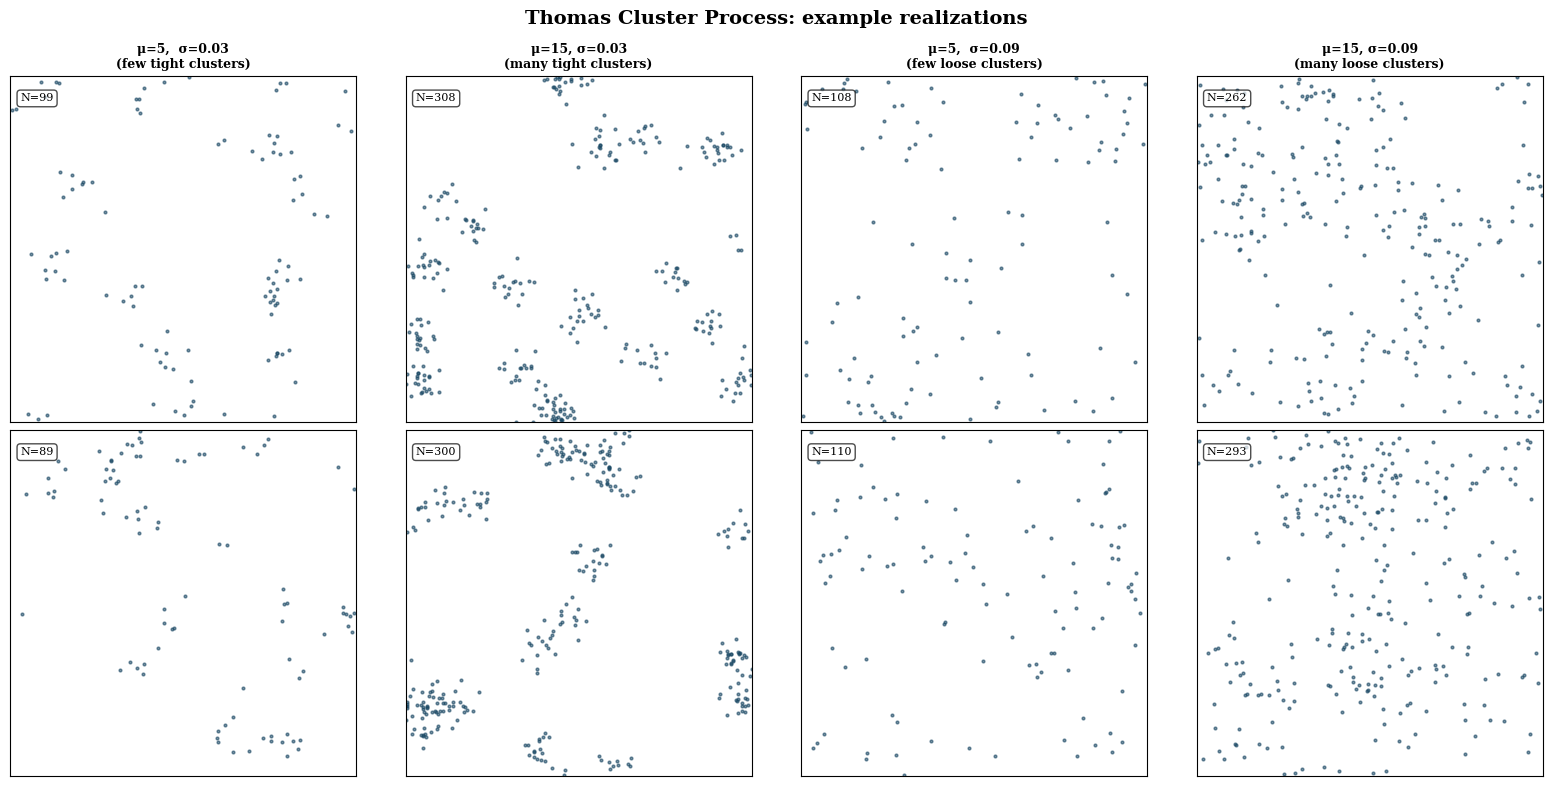

Saved: 1_example_catalogs.png


<Figure size 640x480 with 0 Axes>

In [4]:
# ── Figure 1: Thomas process parameter space exploration ───────────────────────
plt.rcParams['text.usetex'] = False
fig = T.plot_example_catalogs(RNG)

plt.tight_layout(pad=1.5)
plt.show()

## 2 · Summary Statistics

The raw catalog is a **variable-length, unordered point cloud**, we cannot feed it directly to a fixed-size neural network.  We compress it into a **5-dimensional summary vector**:

$$
\mathbf{s} = (s_0,\, s_1,\, s_2,\, s_3,\, s_4)
$$

In [5]:
# ── Compute summary stats for the mock observation ────────────────────────────
stats_obs = T.compute_summary(x_obs)

stat_names = [
    r"$s_0$ = log(1+N)/5",
    r"$s_1$ = mean NN dist × 10",
    r"$s_2$ = std NN dist × 10",
    r"$s_3$ = compactness / 20",
    r"$s_4$ = Ripley $L-r$ × 5",
]

print("Summary statistics for the mock observation:")
print("-" * 45)
for name, val in zip(stat_names, stats_obs):
    print(f"  {name:<28} = {val:.5f}")

Summary statistics for the mock observation:
---------------------------------------------
  $s_0$ = log(1+N)/5           = 1.07598
  $s_1$ = mean NN dist × 10    = 0.27836
  $s_2$ = std NN dist × 10     = 0.16677
  $s_3$ = compactness / 20     = 0.17593
  $s_4$ = Ripley $L-r$ × 5     = 0.13416


### 2.1 Sensitivity to $\mu$ and $\sigma$

Let's verify that each statistic varies monotonically with each parameter.

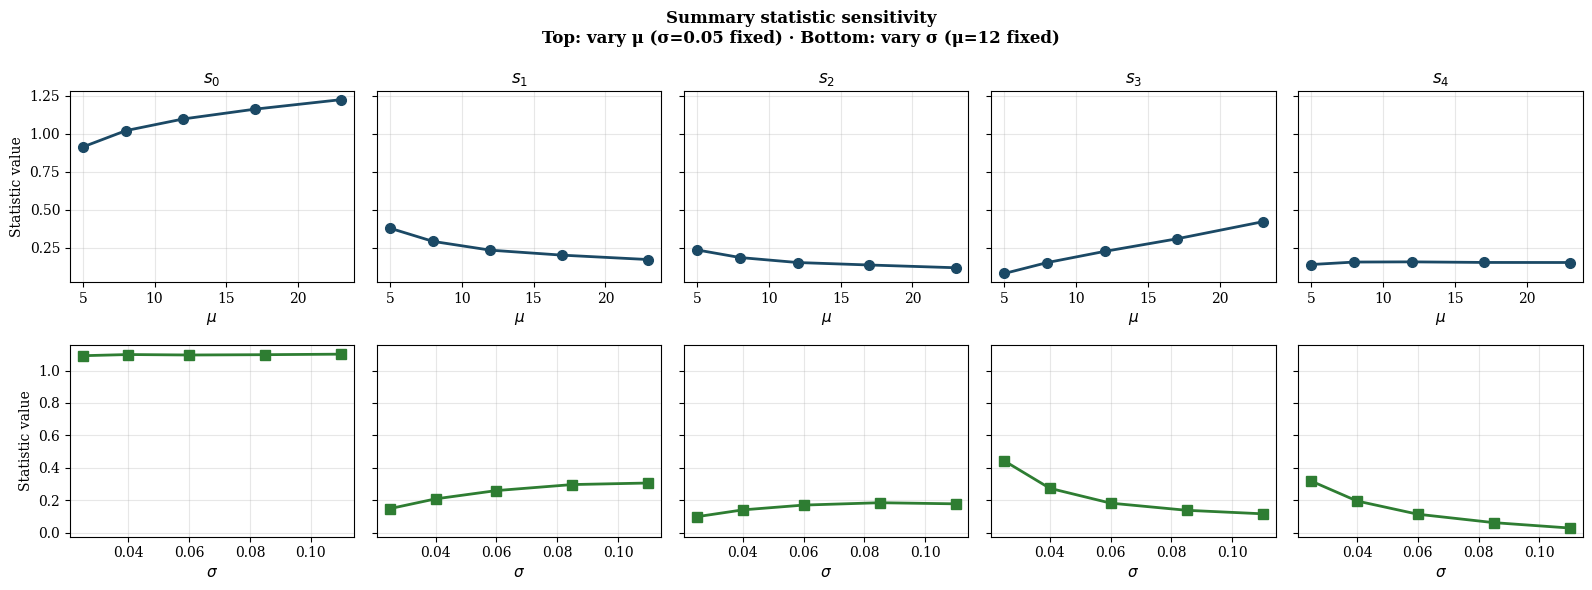


Key observations:
  s0 (count) increases strongly with μ: 0.913 → 1.224
  s1 (NN dist) decreases with σ:        0.306 → 0.148
  s4 (Ripley L) reacts to both μ and σ


In [6]:
rng_sens = np.random.default_rng(7)
n_reps   = 15   # realizations per parameter value

mu_vals    = [5, 8, 12, 17, 23]
sigma_vals = [0.025, 0.04, 0.06, 0.085, 0.11]

# ── Vary μ (fix σ = 0.05) ────────────────────────────────────────────────────
stats_mu = np.zeros((len(mu_vals), T.N_STATS))
for i, mu in enumerate(mu_vals):
    cats = [T.simulate_thomas(mu, 0.05, rng_sens) for _ in range(n_reps)]
    stats_mu[i] = np.mean([T.compute_summary(c) for c in cats], axis=0)

# ── Vary σ (fix μ = 12) ──────────────────────────────────────────────────────
stats_sigma = np.zeros((len(sigma_vals), T.N_STATS))
for i, sig in enumerate(sigma_vals):
    cats = [T.simulate_thomas(12.0, sig, rng_sens) for _ in range(n_reps)]
    stats_sigma[i] = np.mean([T.compute_summary(c) for c in cats], axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, T.N_STATS, figsize=(16, 6), sharey="row")
fig.suptitle("Summary statistic sensitivity\n"
             "Top: vary μ (σ=0.05 fixed) · Bottom: vary σ (μ=12 fixed)",
             fontsize=12, fontweight="bold")

colors_mu    = plt.cm.Blues(np.linspace(0.4, 0.9, len(mu_vals)))
colors_sigma = plt.cm.Greens(np.linspace(0.4, 0.9, len(sigma_vals)))
short_names  = [r"$s_0$", r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$"]

for j in range(T.N_STATS):
    ax = axes[0, j]
    ax.plot(mu_vals, stats_mu[:, j], "o-", c="#1B4965", lw=2, ms=7)
    ax.set_title(short_names[j], fontsize=12, fontweight="bold")
    ax.set_xlabel(r"$\mu$", fontsize=11)
    if j == 0: ax.set_ylabel("Statistic value", fontsize=10)
    ax.grid(True, alpha=0.3)

    ax = axes[1, j]
    ax.plot(sigma_vals, stats_sigma[:, j], "s-", c="#2E7D32", lw=2, ms=7)
    ax.set_xlabel(r"$\sigma$", fontsize=11)
    if j == 0: ax.set_ylabel("Statistic value", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"  s0 (count) increases strongly with μ: {stats_mu[0,0]:.3f} → {stats_mu[-1,0]:.3f}")
print(f"  s1 (NN dist) decreases with σ:        {stats_sigma[-1,1]:.3f} → {stats_sigma[0,1]:.3f}")
print(f"  s4 (Ripley L) reacts to both μ and σ")

---
## 3 · Generating Training Data

For each training simulation $i = 1, \ldots, N_{\text{train}}$:

1. Draw $(\mu_i, \sigma_i) \sim \mathcal{U}[\text{prior}]$.
2. Simulate catalog $\{x_j\}_i \sim \text{Thomas}(\mu_i, \sigma_i)$.
3. Compute $\mathbf{s}_i = \text{summary}(\{x_j\}_i)$.
4. Normalise $(\mu_i, \sigma_i) \to [-1,1]^2$.

The training set is therefore $\{(\tilde{\theta}_i, \mathbf{s}_i)\}_{i=1}^{N}$,
where $\tilde\theta$ denotes the normalised parameters.

In [7]:
N_TRAIN = 3_000

print(f"Generating {N_TRAIN} training simulations …")
t0 = time.time()

theta_train, stats_train = T.generate_training_data(N_TRAIN, RNG)

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s  ({elapsed/N_TRAIN*1000:.1f} ms per simulation)")
print(f"θ shape   : {theta_train.shape}   (normalised to [-1, 1]²)")
print(f"Stats shape: {stats_train.shape}")

Generating 3000 training simulations …
Done in 2.7s  (0.9 ms per simulation)
θ shape   : (3000, 2)   (normalised to [-1, 1]²)
Stats shape: (3000, 5)


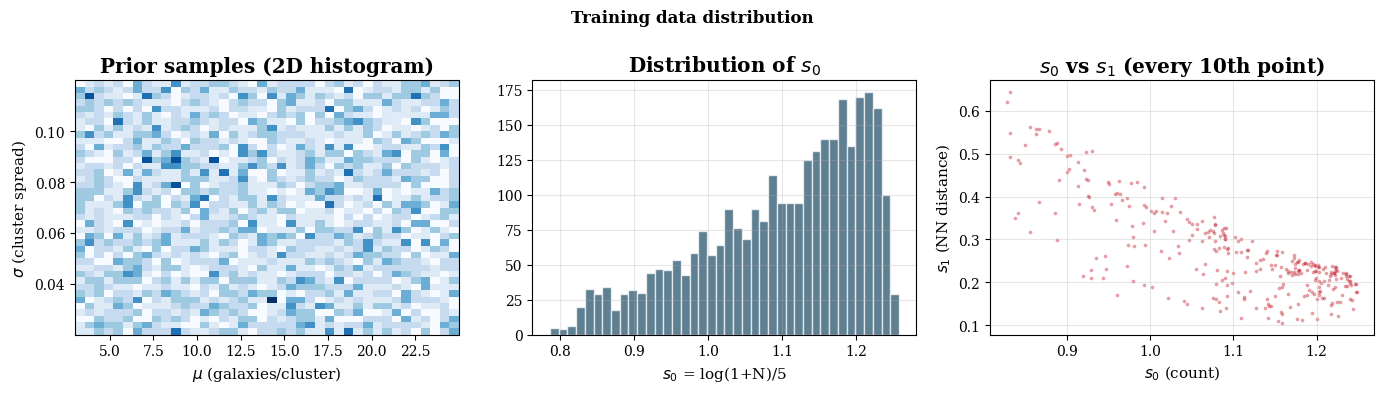


Summary statistics range:
  s0: [0.786, 1.258]
  s1: [0.084, 0.690]
  s2: [0.058, 0.410]
  s3: [0.017, 1.336]
  s4: [-0.023, 0.458]


In [8]:
# ── Inspect the training distribution ────────────────────────────────────────
theta_phys = T.unnormalise(theta_train)   # back to (μ, σ) units

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Training data distribution", fontsize=12, fontweight="bold")

axes[0].hist2d(theta_phys[:,0], theta_phys[:,1], bins=40,
               cmap="Blues", density=True)
axes[0].set_xlabel(r"$\mu$ (galaxies/cluster)", fontsize=11)
axes[0].set_ylabel(r"$\sigma$ (cluster spread)", fontsize=11)
axes[0].set_title("Prior samples (2D histogram)", fontweight="bold")

axes[1].hist(stats_train[:,0], bins=40, color="#1B4965", alpha=0.7,
             edgecolor="white")
axes[1].set_xlabel(r"$s_0$ = log(1+N)/5", fontsize=11)
axes[1].set_title(r"Distribution of $s_0$", fontweight="bold")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(stats_train[::10, 0], stats_train[::10, 1],
                s=3, alpha=0.3, c="#C1121F")
axes[2].set_xlabel(r"$s_0$ (count)", fontsize=11)
axes[2].set_ylabel(r"$s_1$ (NN distance)", fontsize=11)
axes[2].set_title(r"$s_0$ vs $s_1$ (every 10th point)", fontweight="bold")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSummary statistics range:")
snames = ["s0","s1","s2","s3","s4"]
for i, s in enumerate(snames):
    print(f"  {s}: [{stats_train[:,i].min():.3f}, {stats_train[:,i].max():.3f}]")

## 4 · The Normalizing Flow — Real-NVP

In [9]:
# ── Instantiate and inspect the flow ─────────────────────────────────────────
flow = T.RealNVP(context_dim=T.N_STATS, hidden=64, n_layers=3)
flow.to(DEVICE)

n_params = sum(p.numel() for p in flow.parameters())
print(f"Real-NVP architecture:")
print(f"  Coupling layers  : {flow.n_layers}")
print(f"  Fixed-dim order  : {flow.fixed_dims}  (alternating)")
print(f"  Transf-dim order : {flow.transf_dims}")
print(f"  Total parameters : {n_params:,}")
print("Coupling network structure:")
for i, net in enumerate(flow.nets):
    n = sum(p.numel() for p in net.parameters())
    print(f"  Layer {i}: CouplingNet  ->  {n:,} params")

Real-NVP architecture:
  Coupling layers  : 3
  Fixed-dim order  : [0, 1, 0]  (alternating)
  Transf-dim order : [1, 0, 1]
  Total parameters : 14,214
Coupling network structure:
  Layer 0: CouplingNet  ->  4,738 params
  Layer 1: CouplingNet  ->  4,738 params
  Layer 2: CouplingNet  ->  4,738 params


In [10]:
# ── Test: forward pass and sampling ──────────────────────────────────────────
# Use a single summary vector (the observed one) as context
st_t = torch.from_numpy(stats_obs[None]).float().to(DEVICE)     # (1, 5)
th_t = torch.zeros(1, 2).to(DEVICE)                             # dummy θ = (0,0)

with torch.no_grad():
    z, log_det = flow.forward(th_t, st_t)
    log_base   = -0.5 * (z**2).sum(dim=-1) - np.log(2*np.pi)
    log_p      = log_base + log_det

In [11]:
print("Training the Real-NVP flow …")
t0 = time.time()

losses = T.train_flow(
    flow, theta_train, stats_train,
    n_epochs   = 300,
    batch_size = 128,
    lr         = 3e-4,
    device     = DEVICE,
)

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed:.0f}s  ({elapsed/60:.1f} min)")
print(f"Initial loss : {losses[0]:.4f}")
print(f"Final loss   : {losses[-1]:.4f}")
print(f"Improvement  : {losses[0] - losses[-1]:.4f}")

Training the Real-NVP flow …
  Epoch   50/300: loss = -1.3761   lr = 2.81e-04
  Epoch  100/300: loss = -1.4872   lr = 2.28e-04
  Epoch  150/300: loss = -1.5264   lr = 1.55e-04
  Epoch  200/300: loss = -1.5555   lr = 8.25e-05
  Epoch  250/300: loss = -1.5682   lr = 2.94e-05
  Epoch  300/300: loss = -1.5735   lr = 1.00e-05

Training complete in 9s  (0.2 min)
Initial loss : 1.8309
Final loss   : -1.5735
Improvement  : 3.4044


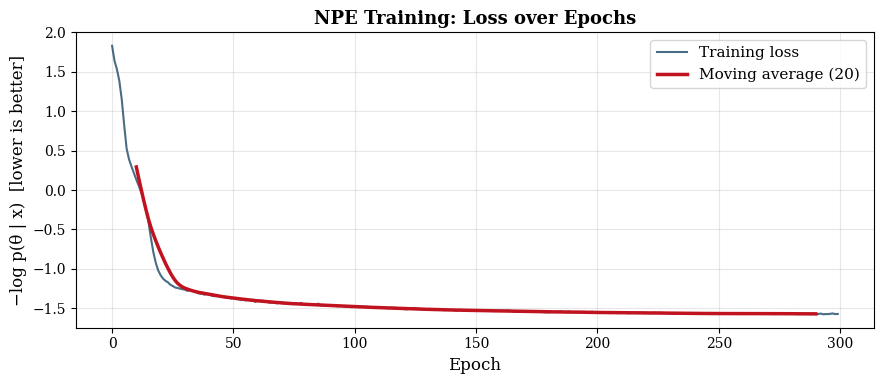

Saved: 2_training_loss.png


<Figure size 640x480 with 0 Axes>

In [12]:
# ── Figure 2 · Training loss curve ───────────────────────────────────────────
T.plot_training_loss(losses)
plt.suptitle("Figure 2 · NPE training loss over 300 epochs",
             y=1.01, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 · Posterior Inference — **Figure 3**

Once the flow is trained, sampling from $p(\mu, \sigma \mid \mathbf{s}_{\rm obs})$
is a single forward pass through the inverse network:

$$
z \sim \mathcal{N}(\mathbf{0}, \mathbf{I}),
\quad
\tilde\theta = f_\phi^{-1}(z;\, \mathbf{s}_{\rm obs}),
\quad
(\mu, \sigma) = \text{unnormalise}(\tilde\theta).
$$

We draw 5,000 samples and discard those outside the prior.

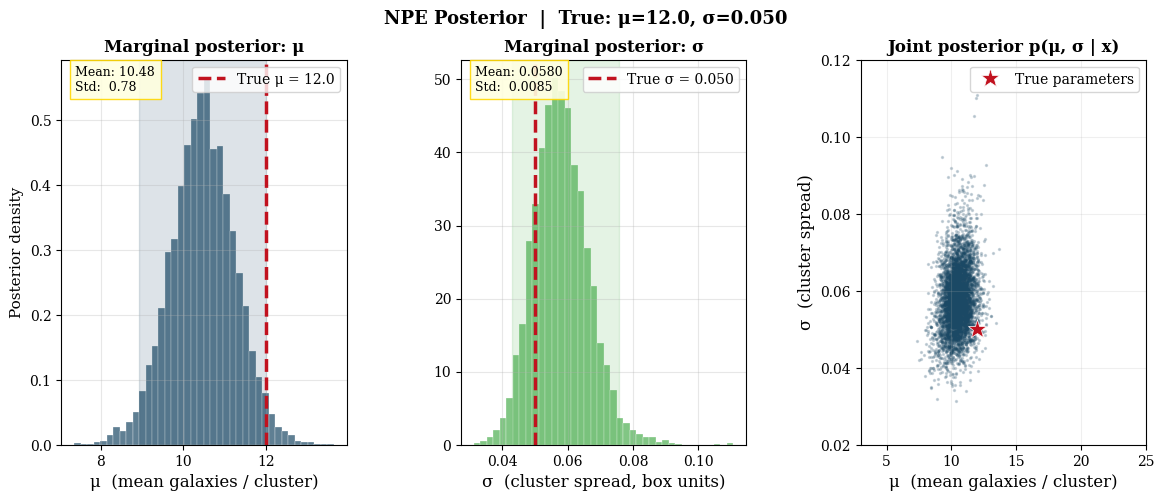

Saved: 3_posterior.png


<Figure size 640x480 with 0 Axes>

In [13]:
# ── Draw posterior samples ────────────────────────────────────────────────────
stats_obs_tensor = T.compute_summary(x_obs)   # recompute to be sure

samples = T.get_posterior_samples(
    flow, stats_obs_tensor,
    n_samples = 5_000,
    device    = DEVICE,
)
T.plot_posterior(samples, MU_TRUE, SIGMA_TRUE)
plt.suptitle("Figure 3 · Inferred posterior for the mock observation",
             y=1.01, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 7 · Posterior Predictive Check — **Figure 6**

A **posterior predictive check** answers: *do simulated catalogs from
the posterior look like the observed data?*

Algorithm:
1. Draw $(\mu_s, \sigma_s) \sim q_\phi(\mu, \sigma \mid \mathbf{s}_{\rm obs})$.
2. Simulate a new catalog $\{x_j\}_s \sim \text{Thomas}(\mu_s, \sigma_s)$.
3. Compute $\mathbf{s}_s$.
4. Compare the distribution of $\mathbf{s}_s$ to the observed $\mathbf{s}_{\rm obs}$.

If the posterior is correct, the observed statistics should lie within the
predictive distribution.

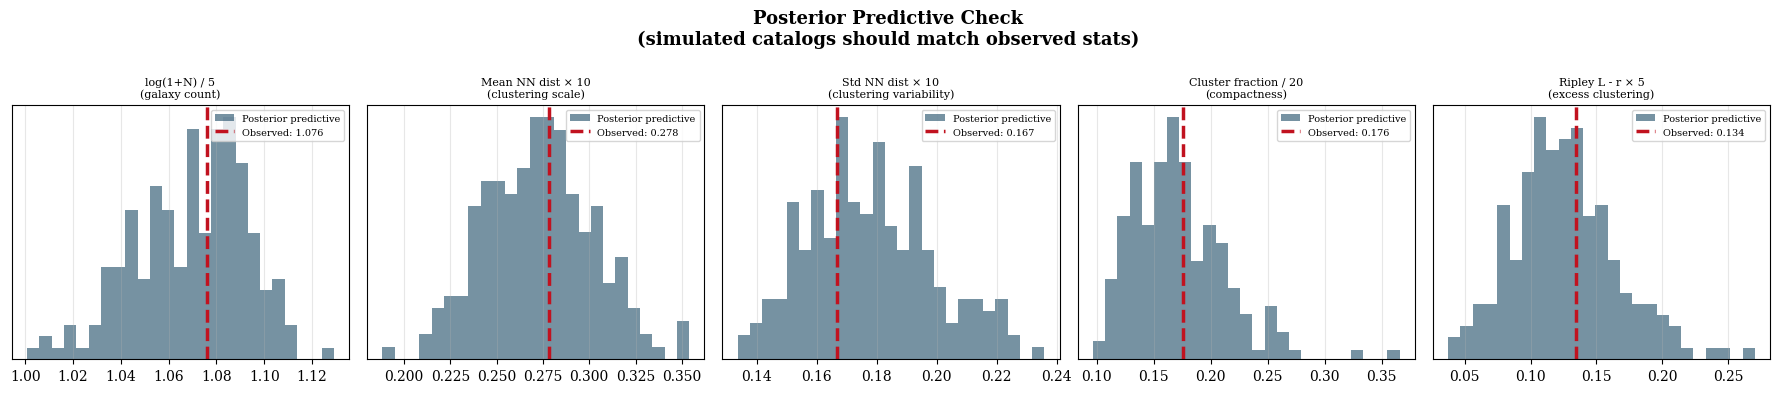

Saved: 6_posterior_predictive.png


<Figure size 640x480 with 0 Axes>

In [14]:
rng_ppc = np.random.default_rng(200)
T.plot_posterior_predictive(
    flow, x_obs, stats_obs_tensor,
    MU_TRUE, SIGMA_TRUE, rng_ppc, DEVICE,
)
plt.suptitle("Figure 6 · Posterior predictive check",
             y=1.01, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8 · Simulation-Based Calibration (SBC) — **Figure 4**

SBC \[Talts et al. 2018\] tests whether the posterior is **calibrated**:

> *If we draw $\theta_{\rm true} \sim p(\theta)$, simulate
> $x \sim p(x \mid \theta_{\rm true})$, and draw $L$ posterior samples,
> the **rank** of $\theta_{\rm true}$ among the samples is uniformly
> distributed on $\{0, 1, \ldots, L\}$.*


**Interpretation of rank histograms:**

* Uniform, Perfectly calibrated
* U-shaped, Posterior too narrow (overconfident) 
* ∩-shaped,  Posterior too wide (underconfident) 
* Skewed left,  Posterior systematically shifted high 
* Skewed right, Posterior systematically shifted low 

In [15]:
t0 = time.time()
sbc_res = T.sbc_validation(
    flow,
    n_tests     = 200,
    n_posterior = 300,
    rng         = np.random.default_rng(55),
    device      = DEVICE,
)
print(f"\nSBC completed in {time.time()-t0:.0f}s")
print(f"\nSBC p-values:")
print(f"  $\mu$ (galaxies/cluster) : p = {sbc_res['p_values'][0]:.4f}  "
      f"{'✓ PASS' if sbc_res['p_values'][0] > 0.05 else '✗ FAIL (increase N_train)'}")
print(f"  $\sigma$ (cluster spread)   : p = {sbc_res['p_values'][1]:.4f}  "
      f"{'✓ PASS' if sbc_res['p_values'][1] > 0.05 else '✗ FAIL (increase N_train)'}")

  Running SBC with 200 tests (L=300)…
    50/200
    100/200
    150/200
    200/200

SBC completed in 0s

SBC p-values:
  $\mu$ (galaxies/cluster) : p = 0.1495  ✓ PASS
  $\sigma$ (cluster spread)   : p = 0.1866  ✓ PASS


/Users/alfonsozapata/Documents/GitHub/NNbasic/thomas_process_npe/thomas_npe.py:867: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/Users/alfonsozapata/Documents/GitHub/NNbasic/thomas_process_npe/thomas_npe.py:868: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.savefig(OUT / "4_sbc.png", dpi=150, bbox_inches="tight")
/opt/anaconda3/envs/sbi_39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


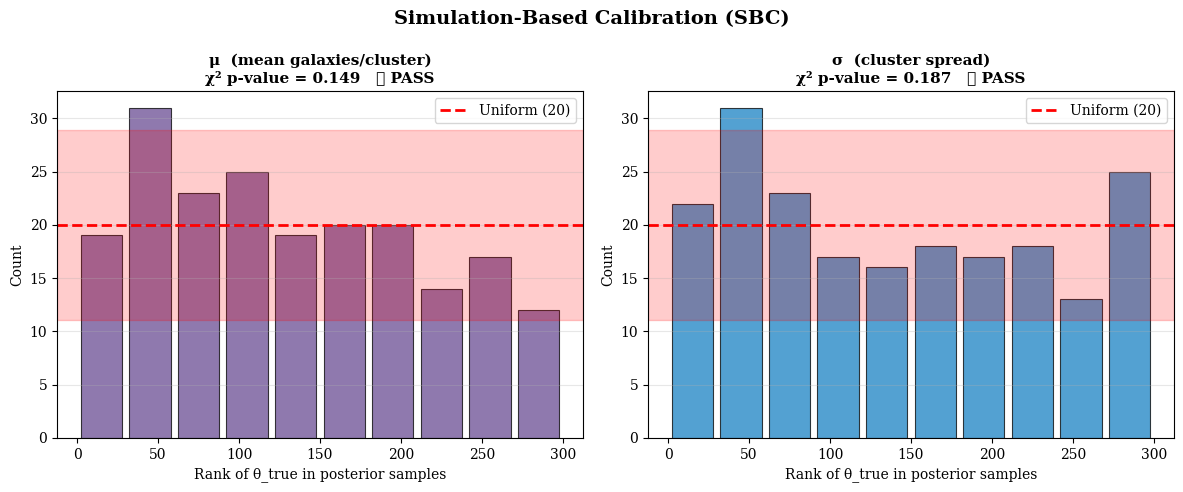

Saved: 4_sbc.png


<Figure size 640x480 with 0 Axes>

In [16]:
T.plot_sbc(sbc_res)
plt.suptitle("Figure 4 · Simulation-Based Calibration (200 trials)",
             y=1.01, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()